# FarmersBot Simulator Model
This section documents the testing of simulator models for the FarmersBot application.

In [ ]:
# The main package needed is PCSE as this is where we will be sourcing the models and some data from.
!pip install pcse

In [ ]:
# Imports
%matplotlib inline
import os
import pcse
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import requests
from pcse.input import PCSEFileReader # Changed from pcse.fileinput which is being phased out
from pcse.base import ParameterProvider
from pcse.fileinput import ExcelWeatherDataProvider
from pcse.fileinput import YAMLAgroManagementReader
from pcse.models import LINTUL3

## Data collection
### Soil data
Main data needed for WOFOST:
+ soil_name = butere_soil, kakamegac_soil, kakamegae_soil, gilgil_soil, kuresoin_soil, kuresois_soil, bumula_soil, bungomac_soil, bungomae_soil
+ SMTAB = volume of soil moisture content as a function of pF
+ CRAIRC = critical soil air content for aeration
+ K0 = hydraulic conductivity of saturated soil
+ SOPE = maximum percolation rate root zone
+ KSUB = maximum percolation rate subsoil
+ RDMSOL = maximum soil rootable depth
+ SPADS = 1st topsoil seepage parameter deep seedbed
+ SPODS = 2nd topsoil seepage parameter deep seedbed
+ SPASS = 1st topsoil seepage parameter shallow seedbed
+ SPOSS = 2nd topsoil seepage parameter shallow seedbed
+ DEFLIM = required moisture deficit deep seedbed

Main data needed for LINTUL is
+ WCAD = water content at air dryness (water content at almost dry, a standard is typically 10% of moisture content or 90% of dry matter)
+ WCWET = Critical Water content for oxygen stress (I don't think its CRAIRC but maybe)
+ DRATE = Maximum drainage rate of the soil (Could be SOPE or KSUB but I'm not sure)

In [ ]:
# Define the subcounties that we will be testing and their latitudes and longitudes
subcounty_lats = [0.21, 0.28, 0.18, -0.50, 0.05, 0.30, 0.55, 0.57, 0.60]
subcounty_lons = [34.49, 34.75, 34.80, 36.32, 35.90, 35.95, 34.50, 34.56, 34.70]
subcounties = ["Butere", "Kakamega Central", "Kakamega East", "Gilgil", "Kuresoi North", "Kuresoi South", "Bumula", "Bungoma Central", "Bungoma East"]

Initially, plan was to use SoilGrids but that didn't work out because the API was down.

In [ ]:
#Function for obtaining WOFOST soil data
def fetch soil parameters(longitude, latitude, filename, soil nane):
  properties = ["1500","933", "bdod", "sand", "clay", "silt", "ocd"] prop_str "".join(properties)
  url = "https://rest.isric.org/soilgrids/v2.8/properties/query?lan={Longitude)&lat={latitude)Sproperties={prop_str)&depth=8-Scn&value=sean"
  response = requests.get(url)

  if response.status_code=200:
    data response.json() parse JSON
  else:
    print(f"Error: {response.status_code}")
    data = None
    return

  soil values = {}
  for layer in data["properties"]["layers"]:
    name = layer["name"]
    if name in properties:
      mean_val = layer["depths"][0]["values"]["mean"]
      soil_values[name] = mean_val

    #Handle missing values by setting defaults
    if not soil_values["bdod"]:
      soil_values["bdod"] = 1.5
    if not soil values["sand"]:
      soil_values["sand"] = 25
    if not soil values["silt"]:
      soil_values["silt"] = 25
    if not soil_values["clay"]:
      soil_values["clay"] = 25
    if not soil values["wv0033"]:
      soil_values["wv0033"] = 0.30
    if not soil values["wv1500"]:
      soil values["wv1500"] = 0.15

    #Division by 100 and 1000 to get values in g/cm^3
    sn0 = (1-((soil_values["bded"]/100)/2.65))
    smfcf = soil_values["wv0033"] / 1000
    smw = soil values["wv1500"]/1000

    #Use the most soil type in the soil
    if max(soil_values["sand"), soil_values["clay"), sail_values["silt") soil_values["sand"]:
      sope 9.8
    elif max(soil_values["sand"), soil_values["clay"), soil_values["silt"]}) == soil_values["clay"]:
      sope 8.4
    else:
      sope 9.2

    craire 0.06
    k=25.586
    ksub = 1.47
    resel = 80
    spads = 0.10

Then I tried to use KENSOTWIS but couldn't find SUID

In [ ]:
!apt-get install mdbtools
!pip install pandas-access

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libmdb3 libmdbsql3
Suggested packages:
  bash-completion
The following NEW packages will be installed:
  libmdb3 libmdbsql3 mdbtools
0 upgraded, 3 newly installed, 0 to remove and 1 not upgraded.
Need to get 136 kB of archives.
After this operation, 486 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libmdb3 amd64 1.0.0+dfsg-1 [68.9 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libmdbsql3 amd64 1.0.0+dfsg-1 [18.8 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 mdbtools amd64 1.0.0+dfsg-1 [48.3 kB]
Fetched 136 kB in 1s (157 kB/s)
Selecting previously unselected package libmdb3:amd64.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../libmdb3_1.0.0+dfsg-1_amd64.deb ...
Unpacking libmdb3:amd64 (1.0.0+dfsg-1)

In [ ]:
import pandas_access as mdb
import numpy as np

np.float_ = np.float64
df = mdb.read_table("/content/KEN_SOTWISv1.mdb", 'SOTERunitComposition')
df.head()

,ISOC,SUID,NEWSUID,SoilMapUnit,SOIL1,PROP1,PRID1,SOIL2,PROP2,PRID2,...,PRID7,SOIL8,PROP8,PRID8,SOIL9,PROP9,PRID9,SOIL10,PROP10,PRID10
0,KE,1,KE1,CMu1 [1],CMu,100,KESYN1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KE,2,KE2,ACh1 [2],ACh,100,KE115/1-12,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KE,3,KE3,LVv3CMv3FLe5 [3],LVv,45,KE115/4-47,CMv,40,KE115/4-45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KE,4,KE4,CMo4ACh4NTr4ACp4 [4],CMo,30,KE115/2-26,ACh,30,KE115/2-35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KE,5,KE5,VRe1FLm5 [5],VRe,85,KE115/4-48,FLm,15,KE115/2-9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Then I tried to use ISRIC-WISE. I realized the data for Kenya is very minimal and incomplete (Note how almost all the data above at the end is NaN)

The method that worked was obtaining data using the SoilGrid's package (https://github.com/gantian127/soilgrids/blob/master/notebooks/soilgrids.ipynb).

No direct units were obtained so computation was needed. I use the functions provided in this paper (# Saxton, K.E. & Rawls, W.J. (2006). Soil water characteristic estimates by texture and organic matter. Soil Science Society of America Journal, 70, 1569–1578) and where functions were unavailable, default values were used

It is important to note that SoilGrids does not provide actual field measurements but rather projections obtained using state of the art ML models (https://www.google.com/url?q=https%3A%2F%2Fisric.org%2Fexplore%2Fsoilgrids)



In [ ]:
!pip install soilgrids

# Subcounties we are working with
subcounty_lats = [0.21, 0.28, 0.18, -0.50, 0.05, 0.30, 0.55, 0.57, 0.60]
subcounty_lons = [34.49, 34.75, 34.80, 36.32, 35.90, 35.95, 34.50, 34.56, 34.70]
subcounties = ["Butere", "Kakamega Central", "Kakamega East", "Gilgil", "Kuresoi North", "Kuresoi South", "Bumula", "Bungoma Central", "Bungoma East"]

# Gan, T. (2023). Jupyter Notebooks for the soilgrids Data Component, HydroShare, https://www.hydroshare.org/resource/7ad709d065274ad2a2a8fd08860513d5/
import matplotlib.pyplot as plt
from soilgrids import SoilGrids

def soilgrids_data(lat, lon):
  buffer = 0.005

  variables = {
    "bdod": "bdod_0-5cm_mean",
    "sand": "sand_0-5cm_mean",
    "clay": "clay_0-5cm_mean",
    "soc":  "soc_0-5cm_mean",
    "cfvo": "cfvo_0-5cm_mean",
  }
  results = {}

  for variable in variables.keys():
    soil_grids = SoilGrids()
    data = soil_grids.get_coverage_data(
        service_id=variable,
        coverage_id=variables[variable],
        west=lon - buffer,
        south=lat - buffer,
        east=lon + buffer,
        north=lat + buffer,
        width=int(((lon+buffer) - (lon-buffer)) / 0.002245),
        height=int(((lat+buffer) - (lat-buffer)) / 0.002245),
        crs="urn:ogc:def:crs:EPSG::4326",
        local_file=False,
        output="test.tif"
    )
    # Some of the results tended to give negative values which are unusable
    # Default values i.e values obtained from Butere subcounty which was the first subcounty were used
    result = float(data.mean().values)
    if result < 0:
      if variable == "bdod":
        result = 120.75
      elif variable == "sand":
        result = 287.8125
      elif variable == "clay":
        result = 481.0
      elif variable == "soc":
        result = 422.25
      if variable == "cfvo":
        result = 114.4375

    results[variable] = result

  return results

# Compute required values
import numpy as np
import math

def compute_data_wofost(lat, lon, subcounty, filename):
  data = soilgrids_data(lat, lon)
  sand = data['sand'] / 1000
  clay = data['clay'] / 1000
  soc = data['soc'] / 100
  OM = (data['soc'] / 100) * 1.724
  bdod = data['bdod'] / 100

  soil_name = f"{subcounty}_soil"

  # SMW = soil moisture content at wilting point [cm3/cm3]
  theta_1500t = (-0.024 * sand) + (0.487 * clay) + (0.006 * OM) + (0.005 * sand * OM) - (0.013 * clay * OM) + (0.068 * sand * clay) + 0.031
  smw = theta_1500t + (0.14 * theta_1500t - 0.02)

  # SMFCF = soil moisture content at field capacity [cm3/cm3]
  theta_33t = (-0.251 * sand) + (0.195 * clay) + (0.011 * OM) + (0.006 * sand * OM) - (0.027 * clay * OM) - (0.452 * sand * clay) + 0.299
  smfcf = theta_33t + ((1.283 * (theta_33t)**2) - (0.374 * theta_33t) - 0.015)

  # SM0 = soil moisture content at saturation [cm3/cm3]
  theta_s33 = (0.278 * sand) + (0.034 * clay) + (0.022 * OM) - (0.018 * sand * OM) - (0.027 * clay * OM) - (0.584 * sand * clay) + 0.078
  s33 = theta_s33 + ((0.636 *theta_s33) - 0.107)
  sm0 = smfcf + s33 - (0.097 * sand) + 0.043

  # K0 = hydraulic conductivity of saturated soil
  B = (math.log(1500) - math.log(33)) / (math.log(smfcf) - math.log(sm0))
  ko = 1930 * (sm0 - smfcf) ** (3 - 1/B)
  ko = ko * 2.4

  # SOPE = maximum percolation rate root zone
  sope = 0.5 * ko

  # KSUB = maximum percolation rate subsoil
  ksub = 0.2 * ko # subsoil conductivity is lower due to compaction

  # Use default values
  crairc = 0.06
  rdmsol = 80
  spads = 0.10
  spods = 0.03
  spass = 0.20
  sposs = 0.05
  deflim = -0.30

  with open(filename, "w") as f:
    f.write(f"** $Id: {soil_name}.new 1.0 2025/11/20 00:00:00 Generated $\n")
    f.write("**\n")
    f.write("** SOIL DATA FILE for use with WOFOST Version 5.0\n")
    f.write("**\n")
    f.write(f"** {soil_name}\n\n")
    f.write(f"SOLNAM='{soil_name}'\n\n")
    f.write("** physical soil characteristics \n\n")
    f.write("** soil water retention\n")
    # SMTAB = volume of soil moisture content as a function of pF
    f.write(f"SMTAB    =  -1.000,   {sm0},    ! vol. soil moisture content\n")
    f.write(f"             2.000,   {smfcf},    ! as function of pF [log (cm); cm3 cm-3]\n")
    f.write(f"             4.200,   {smw}\n")
    f.write(f"SMW      =   {smw}  !  soil moisture content at wilting point [cm3/cm3]\n")
    f.write(f"SMFCF    =   {smfcf}  !  soil moisture content at field capacity [cm3/cm3]\n")
    f.write(f"SM0      =   {sm0}  !  soil moisture content at saturation [cm3/cm3]\n")
    f.write(f"CRAIRC   =   {crairc}  ! critical soil air content for aeration [cm3/cm3]\n\n")
    f.write("** hydraulic conductivity\n")
    f.write(f"K0       =  {ko}  ! hydraulic conductivity of saturated soil [cm day-1]\n")
    f.write(f"SOPE     =   {sope}   ! maximum percolation rate root zone[cm day-1]\n")
    f.write(f"KSUB     =   {ksub}   ! maximum percolation rate subsoil [cm day-1]\n")
    f.write(f"RDMSOL   =   {rdmsol}     ! maximum soil rootable depth [cm]\n\n")
    f.write("** soil workability parameters\n")
    f.write(f"SPADS    =   {spads}  !  1st topsoil seepage parameter deep seedbed\n")
    f.write(f"SPODS    =   {spods}  !  2nd topsoil seepage parameter deep seedbed\n")
    f.write(f"SPASS    =   {spass}  !  1st topsoil seepage parameter shallow seedbed\n")
    f.write(f"SPOSS    =   {sposs}  !  2nd topsoil seepage parameter shallow seedbed\n")
    f.write(f"DEFLIM   =  {deflim}  !  required moisture deficit deep seedbed\n")

  return filename

# Create WOFOST directory
!mkdir WOFOST
data_dir = '/content/WOFOST'

# Obtain soil data for each subcounty
# Some changes were made to the soil file adding underscores to filenames with spaces
for index, subcounty in enumerate(subcounties):
  soil_file = compute_data_wofost(subcounty_lats[index], subcounty_lons[index], subcounty, os.path.join(data_dir, f"{subcounty}_soil.soil"))

def compute_data_lintul(lat, lon, subcounty, filename):
  data = soilgrids_data(lat, lon)
  sand = data['sand'] / 1000
  clay = data['clay'] / 1000
  soc = data['soc'] / 100
  OM = (data['soc'] / 100) * 1.724
  bdod = data['bdod'] / 100

  theta_1500t = (-0.024 * sand) + (0.487 * clay) + (0.006 * OM) + (0.005 * sand * OM) - (0.013 * clay * OM) + (0.068 * sand * clay) + 0.031
  WCWP = theta_1500t + (0.14 * theta_1500t - 0.02)

  WCAD = 0.5 * WCWP # Approximation

  theta_33t = (-0.251 * sand) + (0.195 * clay) + (0.011 * OM) + (0.006 * sand * OM) - (0.027 * clay * OM) - (0.452 * sand * clay) + 0.299
  WCFC = theta_33t + ((1.283 * (theta_33t)**2) - (0.374 * theta_33t) - 0.015)

  theta_s33 = (0.278 * sand) + (0.034 * clay) + (0.022 * OM) - (0.018 * sand * OM) - (0.027 * clay * OM) - (0.584 * sand * clay) + 0.078
  s33 = theta_s33 + ((0.636 *theta_s33) - 0.107)
  WCST = WCFC + s33 - (0.097 * sand) + 0.043

  WCWET = WCST - 0.05 # o.05 obtained from default CRAIRC in WOFOST implementation

  # DRATE is equal to ksat/k0
  B = (math.log(1500) - math.log(33)) / (math.log(WCFC) - math.log(WCST))
  DRATE = 1930 * (WCST - WCFC) ** (3 - 1/B)
  DRATE = DRATE * 2.4

  content = f"""# Soil hydraulic properties
WCAD   = {WCAD}
WCWP   = {WCWP}
WCFC   = {WCFC}
WCWET  = {WCWET}
WCST   = {WCST}
DRATE  = {int(DRATE)}.  			# Maximum drainage rate of the soil (mm/day)
    """
  with open(filename, "w") as f:
    f.write(content)

  return filename

# Create LINTUL directory
!mkdir LINTUL
data_dir = '/content/LINTUL'

# Obtain soil data for each subcounty
# Some changes were made to the soil file adding underscores to filenames with spaces
for index, subcounty in enumerate(subcounties):
  soil_file = compute_data_lintul(subcounty_lats[index], subcounty_lons[index], subcounty, os.path.join(data_dir, f"{subcounty}_soil.soil"))

In [ ]:
# Save to zip folders and save for later
import shutil
shutil.make_archive('/content/WOFOST', 'zip', 'WOFOST')

import shutil
shutil.make_archive('/content/LINTUL', 'zip', 'LINTUL')

### Site data
PCSE's implementation of WOFOST offers a function that allows one to create dummy data.

As for Lintul, the required data was obtained in a similar way to soil data

In [ ]:
def soilgrids_site(lat, lon):
  buffer = 0.005

  variables = {
    "sand": "sand_0-5cm_mean",
    "clay": "clay_0-5cm_mean",
    "soc":  "soc_0-5cm_mean",
  }
  results = {}

  for variable in variables.keys():
    soil_grids = SoilGrids()
    data = soil_grids.get_coverage_data(
        service_id=variable,
        coverage_id=variables[variable],
        west=lon - buffer,
        south=lat - buffer,
        east=lon + buffer,
        north=lat + buffer,
        width=int(((lon+buffer) - (lon-buffer)) / 0.002245),
        height=int(((lat+buffer) - (lat-buffer)) / 0.002245),
        crs="urn:ogc:def:crs:EPSG::4326",
        local_file=False,
        output="test.tif"
    )
    # Some of the results tended to give negative values which are unusable
    # Default values i.e values obtained from Butere subcounty which was the first subcounty were used
    result = float(data.mean().values)
    if result < 0:
      if variable == "sand":
        result = 287.8125
      elif variable == "clay":
        result = 481.0
      elif variable == "soc":
        result = 422.25

    results[variable] = result

  return results

In [ ]:
def compute_site_data(lat, lon, subcounty, filename):
  data = soilgrids_site(lat, lon)
  sand = data['sand'] / 1000
  clay = data['clay'] / 1000
  soc = data['soc'] / 100
  OM = (data['soc'] / 100) * 1.724

  # Assumption of WCI is 50% of field capacity since expert opinion is unavailable (Yieldgap.org, 2015)
  theta_33t = (-0.251 * sand) + (0.195 * clay) + (0.011 * OM) + (0.006 * sand * OM) - (0.027 * clay * OM) - (0.452 * sand * clay) + 0.299
  smfcf = theta_33t + ((1.283 * (theta_33t)**2) - (0.374 * theta_33t) - 0.015)
  WCI = 50/100 * smfcf

  # Obtain WCSUBS wilting point - field capacity
  theta_1500t = (-0.024 * sand) + (0.487 * clay) + (0.006 * OM) + (0.005 * sand * OM) - (0.013 * clay * OM) + (0.068 * sand * clay) + 0.031
  smw = theta_1500t + (0.14 * theta_1500t - 0.02)
  WCSUBS = smw - smfcf

  content = f"""# initial soil conditions
WCI    = {WCI} 			# Initial water content in cm3 of water/(cm3 of soil).
WCSUBS = {WCSUBS} 			# water content subsoil

# Water management
# We will represent two water management situations in the model
# as irrigated up to the field capacity:  WMFAC = False
# as irrigated up to saturation, thus mimicking flooding; WMFAC = True
# In both cases parameter IRRIGF must be taken 1.0. "Irrigation" thus
WMFAC  = False
IRRIGF = False			# Irrigation factor
  """
  with open(filename, "w") as f:
    f.write(content)

import os

subcounty_lats = [0.21, 0.28, 0.18, -0.50, 0.05, 0.30, 0.55, 0.57, 0.60]
subcounty_lons = [34.49, 34.75, 34.80, 36.32, 35.90, 35.95, 34.50, 34.56, 34.70]
subcounties = ["Butere", "Kakamega Central", "Kakamega East", "Gilgil", "Kuresoi North", "Kuresoi South", "Bumula", "Bungoma Central", "Bungoma East"]

# Create LINTUL directory
!mkdir LINTUL_SITE
data_dir = '/content/LINTUL_SITE'

# Obtain soil data for each subcounty
# Some changes were made to the soil file adding underscores to filenames with spaces
for index, subcounty in enumerate(subcounties):
  soil_file = compute_site_data(subcounty_lats[index], subcounty_lons[index], subcounty, os.path.join(data_dir, f"{subcounty}_soil.site"))

import shutil
shutil.make_archive('/content/LINTUL_SITE', 'zip', 'LINTUL_SITE')

### Crop data
The crop data for LINTUL was mostly obtained from the same source as WOFOST (https://edepot.wur.nl/218353 ) for consistency. However, since PCSE does not have a function that allows direct access to the data for LINTUL as is the case for WOFOST, the data had to be manually input. Default values from the example springwheat file offered by PCSE were used in cases where data could not be found.

In [ ]:
maize_params = {
    "WLVGI": "12.4", # First FLTB * initial total crop dry weight
    "WSTI": "7.6", # First FSTB * initial total crop dry weight
    "WRTLI": "8", # First FRTB * initial total crop dry weight
    "WSOI": "0", # First FOTB * initial total crop dry weight
    "ROOTDI": "10", #RDI
    "DVSDR": "1.51", #  RDRSTB (first value where a 0 appears)
    "DVSNLT": "0.40", # NMAXLV_TB (DVS highest value)
    "DVSNT": "0.70", # NMAXLV_TB (DVS where the N starts to decrease)
    "FNTRT": "0.50", # NPK_TRANSLRT_FR
    "FRNX": "1.00", # NCRIT_FR
    "K": "0.650", #KDIF
    "LAICR": "4.0",
    "LRNR": "0.500", # NMAXRT_FR
    "LSNR": "0.500", # NMAXST_FR
    "LUE": "0.45", #EFF
    "NFRLVI": "0.0600", # NMAXLV_TB (first value)
    "NFRRTI": "0.03",
    "NFRSTI": "0.03",
    "NLAI": "1.00", # NPART
    "NLUE": "0.20",
    "NMAXSO": "0.0220", #NMAXSO
    "NPART": "1.0",
    "NSLA": "1.0",
    "RDRRT": "0.020", #Largest val in RDRSTB
    "RDRSHM": "0.03",
    "RGRL": "0.0294", #RGRLAI
    "RNFLV": "0.0053", #NRESIDLV
    "RNFRT": "0.0027", # NRESIDRT
    "RNFST": "0.0027",# NRESIDST
    "ROOTDM": "1", #RDMCR/100
    "RRDMAX": "0.015", #RRI/100
    "SLAC": "0.022",
    "TBASE": "0",
    "TCNT": "10",
    "TRANCO": "1", #CFET
    "TSUMAG": "800",
    "RDRT": "[-10., 0.00, 10., 0.02, 15., .03, 30., 0.05, 50., 0.09 ]",
    "SLACF": "[0.0, 0.0035, 2.0, 0.0016, 2.1, 0.0016 ]", #SLATB
    "NMXLV": "[0.0, 0.0125, 0.4, 0.0100, 0.7, 0.0080, 1.0, 0.0060, 2.0, 0.0040, 2.1, 0.0040]", #NMAXVE
    "FRTTB": "[0.0, 0.20, 0.33, 0.31, 0.40, 0.10, 0.80, 0.00, 1.00, 0.00, 2.00, 0.0 ]", #FRTB
    "FLVTB": "[0.0, 0.70, 0.33, 0.15, 0.40, 0.15, 0.80, 0.15, 1.00, 0.00, 1.01, 0.00, 2.00, 0.00]", #FLTB
    "FSTTB": "[0.0, 0.10, 0.33, 0.54, 0.40, 0.75, 0.80, 0.85, 1.00, 1.00, 1.01, 0.00, 2.00, 0.00]", #FSTB
    "FSOTB": "[0.0, 0.00, 0.33, 0.00, 0.40, 0.00, 0.80, 0.00, 1.00, 0.00, 1.01, 1.00, 2.00, 1.00]", #FOTB
    "TBASEM": "4.0", #TBASEM
    "TEFFMX": "30.0", #TEFFMX
    "TSUMEM": "110", #TSUNEM
    "IDSL": "0", #IDSL
    "DLO": "-99", #DLO
    "DLC": "-99", #DLC
    "TSUM1": "693", #TSUM1
    "TSUM2": "786", #TSUM2
    "DTSMTB1": "0.00", #DTSMTB
    "DTSMTB2": "24.00",
    "DVSI": "0",
    "DVSEND": "2.5", #DVSEND
    "RDRNS": "0.05", # RDRLV_NPK
    "RDRRT": "0.020", # RDRSTB
    "RNMIN": "0.00"
}

In [ ]:
sunflower_params = {
    "date": "16-Apr-2015, 11:44:49",
    "source_file": "Varied",
    "WLVGI": "2.4",
    "WSTI": "0.6",
    "WRTLI": "3",
    "WSOI": "0",
    "ROOTDI": "10",
    "DVSDR": "1.5",
    "DVSNLT": "0.00",
    "DVSNT": "0.40",
    "FNTRT": "0.50",
    "FRNX": "1.00",
    "K": "0.900",
    "LAICR": "4.0",
    "LRNR": "0.500",
    "LSNR": "0.500",
    "LUE": "0.900",
    "NFRLVI": "0.0600",
    "NFRRTI": "0.03",
    "NFRSTI": "0.03",
    "NLAI": "1.00",
    "NLUE": "0.20",
    "NMAXSO": "0.0450",
    "NPART": "1.0",
    "NSLA": "1.0",
    "RDRRT": "0.020",
    "RDRSHM": "0.03",
    "RGRL": "0.0294",
    "RNFLV": "0.00933",
    "RNFRT": "0.00467",
    "RNFST": "0.00467",
    "ROOTDM": "1.50",
    "RRDMAX": "0.012",
    "SLAC": "0.022",
    "TBASE": "0",
    "TCNT": "10",
    "TRANCO": "1",
    "TSUMAG": "800",
    "RDRT": "[-10., 0.00, 10., 0.02, 15., .03, 30., 0.05, 50., 0.09 ]",
    "SLACF": "[0.0, 0.0035, 2.0, 0.0025, 2.1, 0.0025]",
    "NMXLV": "[0.0, 0.0600, 0.4, 0.0400, 0.7, 0.0300, 1.0, 0.0300, 2.0, 0.0240, 2.1, 0.0240]",
    "FRTTB": "[0.0, 0.50, 0.33, 0.33, 0.40, 0.33, 0.80, 0.00, 1.00, 0.00, 2.00, 0.00]",
    "FLVTB": "[0.0, 0.40, 0.33, 0.33, 0.40, 0.33, 0.80, 0.50, 1.00, 0.20, 1.01, 0.00, 2.00, 0.00]",
    "FSTTB": "[0.0, 0.10, 0.33, 0.34, 0.40, 0.34, 0.80, 0.50, 1.00, 0.28, 1.01, 0.00, 2.00, 0.00]",
    "FSOTB": "[0.0, 0.00, 0.33, 0.00, 0.40, 0.00, 0.80, 0.00, 1.00, 0.52, 1.01, 1.00, 2.00, 1.00]",
    "TBASEM": "3",
    "TEFFMX": "32",
    "TSUMEM": "130",
    "IDSL": "0",
    "DLO": "-99",
    "DLC": "-99",
    "TSUM1": "1050",
    "TSUM2": "1000",
    "DTSMTB1": "0.00",
    "DTSMTB2": "38.00",
    "DVSI": "0",
    "DVSEND": "2.00",
    "RDRNS": "0.05",
    "RDRRT": "0.020",
    "RNMIN": "0.00"
}

In [ ]:
cowpeas_params = {
    "date": "16-Apr-2015, 11:44:49",
    "source_file": "Varied",
    "WLVGI": "0",
    "WSTI": "2.8",
    "WRTLI": "5.2",
    "WSOI": "0",
    "ROOTDI": "10.0",
    "DVSDR": "1.51",
    "DVSNLT": "0.040",
    "DVSNT": "2.00",
    "FNTRT": "0.50",
    "FRNX": "1.00",
    "K": "0.800",
    "LAICR": "4.0",
    "LRNR": "0.500",
    "LSNR": "0.500",
    "LUE": "0.32",
    "NFRLVI": "0.0600",
    "NFRRTI": "0.03",
    "NFRSTI": "0.03",
    "NLAI": "1.00",
    "NLUE": "0.20",
    "NMAXSO": "0.0480",
    "NPART": "1.0",
    "NSLA": "1.0",
    "RDRRT": "0.02",
    "RDRSHM": "0.03",
    "RGRL": "0.0500",
    "RNFLV": "0.0107",
    "RNFRT": "0.0053",
    "RNFST": "0.0053",
    "ROOTDM": "1.20",
    "RRDMAX": "0.012",
    "SLAC": "0.022",
    "TBASE": "0",
    "TCNT": "10",
    "TRANCO": "1",
    "TSUMAG": "800",
    "RDRT": "[-10., 0.00, 10., 0.02, 15., .03, 30., 0.05, 50., 0.09 ]",
    "SLACF": "[0.0, 0.0040, 2.0, 0.0032, 2.1, 0.0032 ]",
    "NMXLV": "[0.0, 0.0600, 0.4, 0.0400, 0.7, 0.0400, 1.0, 0.0400, 2.0, 0.0360, 2.1, 0.0360]",
    "FRTTB": "[0.0, 0.65, 0.33, 0.65, 0.40, 0.65, 0.80, 0.65, 1.00, 0.00, 2.00, 0.0 ]",
    "FLVTB": "[0.0, 0.35, 0.33, 0.35, 0.40, 0.35, 0.80, 0.35, 1.00, 0.61, 1.01, 0.44, 2.00, 0.00]",
    "FSTTB": "[0.0, 0.00, 0.33, 0.00, 0.40, 0.00, 0.80, 0.00, 1.00, 0.39, 1.01, 0.00, 2.00, 0.00]",
    "FSOTB": "[0.0, 0.00, 0.33, 0.00, 0.40, 0.00, 0.80, 0.00, 1.00, 0.00, 1.01, 0.56, 2.00, 1.00]",
    "TBASEM": "10.0",
    "TEFFMX": "30.0",
    "TSUMEM": "70",
    "IDSL": "0",
    "DLO": "1",
    "DLC": "0",
    "TSUM1": "660",
    "TSUM2": "630",
    "DTSMTB1": "0.0",
    "DTSMTB2": "20.0",
    "DVSI": "0.0",
    "DVSEND": "2.0",
    "RDRNS": "0.05",
    "RDRRT": "0.020",
    "RNMIN": "0.00"
}

In [ ]:
millet_params = {
    "date": "16-Apr-2015, 11:44:49",
    "source_file": "Varied",
    "WLVGI": "6",
    "WSTI": "2.4",
    "WRTLI": "3.6",
    "WSOI": "0",
    "ROOTDI": "10",
    "DVSDR": "1.51",
    "DVSNLT": "0.00",
    "DVSNT": "0.40",
    "FNTRT": "0.50",
    "FRNX": "1.00",
    "K": "0.500",
    "LAICR": "4.0",
    "LRNR": "0.500",
    "LSNR": "0.500",
    "LUE": "0.380",
    "NFRLVI": "0.0600",
    "NFRRTI": "0.03",
    "NFRSTI": "0.03",
    "NLAI": "1.00",
    "NLUE": "0.20",
    "NMAXSO": "0.0160",
    "NPART": "1.0",
    "NSLA": "1.0",
    "RDRRT": "0.020",
    "RDRSHM": "0.03",
    "RGRL": "0.0500",
    "RNFLV": "0.0043",
    "RNFRT": "0.0021",
    "RNFST": "0.0021",
    "ROOTDM": "2.20",
    "RRDMAX": "0.04",
    "SLAC": "0.022",
    "TBASE": "0",
    "TCNT": "10",
    "TRANCO": "1.00",
    "TSUMAG": "800",
    "RDRT": "[-10., 0.00, 10., 0.02, 15., .03, 30., 0.05, 50., 0.09 ]",
    "SLACF": "[0.0, 0.00180, 2.0, 0.0018, 2.1, 0.0016 ]",
    "NMXLV": "[0.0, 0.0600, 0.4, 0.0400, 0.7, 0.0300, 1.0, 0.0200, 2.0, 0.0140, 2.1, 0.0140]",
    "FRTTB": "[0.0, 0.30, 0.33, 0.31, 0.40, 0.10, 0.80, 0.10, 1.00, 0.00, 2.00, 0.0 ]",
    "FLVTB": "[0.0, 0.50, 0.33, 0.15, 0.40, 0.15, 0.80, 0.15, 1.00, 0.00, 1.01, 0.00, 2.00, 0.00]",
    "FSTTB": "[0.0, 0.20, 0.33, 0.54, 0.40, 0.75, 0.80, 0.75, 1.00, 1.00, 1.01, 0.00, 2.00, 0.00]",
    "FSOTB": "[0.0, 0.00, 0.33, 0.00, 0.40, 0.00, 0.80, 0.00, 1.00, 0.00, 1.01, 1.00, 2.00, 1.00]",
    "TBASEM": "12.0",
    "TEFFMX": "32.0",
    "TSUMEM": "60",
    "IDSL": "0",
    "DLO": "1",
    "DLC": "0",
    "TSUM1": "772",
    "TSUM2": "483",
    "DTSMTB1": "0.00",
    "DTSMTB2": "17.00",
    "DVSI": "0",
    "DVSEND": "2.0",
    "RDRNS": "0.05",
    "RDRRT": "0.020",
    "RNMIN": "0.00"
}

In [ ]:
def fetch_crop_data(date, source_file, params, filename):
  content = f"""# ----------------------------------------------------------------------#
# Information about this file                                          #
# ===========================                                          #
# Contents      : Model data file                                      #
# Creator       : FST translator version 4.00                          #
# Creation date : {date}                                #
# Source file   : {source_file}                        #
# ----------------------------------------------------------------------#

# contains:
# - Initial constants as far as specified with INCON statements,
# - Model parameters,
# - AFGEN/CSPLIN interpolation functions,
# - A SCALE array in case of a general translation

# Initial constants
# -----------------
DVSI  = 0.
WLVGI  = {params["WLVGI"]}
WSTI   = {params["WSTI"]}
WRTLI  = {params["WRTLI"]}
WSOI   = {params["WSOI"]}

# initial rooting depth
ROOTDI = {params["ROOTDI"]}

DVSDR  = {params["DVSDR"]}            # Development stage above which death of leaves and roots start.
DVSNLT = {params["DVSNLT"]}            # development stage N-limit
DVSNT  = {params["DVSNT"]}            # development stage N-threshold
FNTRT  = {params["FNTRT"]}           # Nitrogen translocation from roots as a fraction of the total amount of nitrogen translocated from leaves and stem.
FRNX   = {params["FRNX"]}            # Optimal N concentration as the fraction of maximum N concentration.
K      = {params["K"]}            # light extinction coefficient
LAICR  = {params["LAICR"]}            # (oC d)-1, critical LAI above which mutual shading of leaves occurs,
LRNR   = {params["LRNR"]}
LSNR   = {params["LSNR"]}
LUE    = {params["LUE"]}            # Light use efficiency.
NFRLVI = {params["NFRLVI"]}           # Initial fraction of N (g N g-1 DM) in leaves.
NFRRTI = {params["NFRRTI"]}           # Initial fraction of N (g N g-1 DM) in roots.
NFRSTI = {params["NFRSTI"]}           # Initial fraction of N (g N g-1 DM) in stem.
NLAI   = {params["NLAI"]}            # Coefficient for the effect of N stress on LAI reduction(during juvenile phase)
NLUE   = {params["NLUE"]}           # Extinction coefficient for  Nitrogen distribution down the canopy
NMAXSO = {params["NMAXSO"]}
NPART  = {params["NPART"]}            # Coefficient for the effect of N stress on leaf biomass reduction
NSLA   = {params["NSLA"]}            # Coefficient for the effect of N stress on SLA reduction
RDRRT  = {params["RDRRT"]}           # Relative death rate of roots.
RDRSHM = {params["RDRSHM"]}           # and the maximum relative death rate of leaves due to shading.
RGRL   = {params["RGRL"]}          # Relative growth rate of LAI at the exponential growth phase
RNFLV  = {params["RNFLV"]}          # Residual N concentration in leaves
RNFRT  = {params["RNFRT"]}          # Residual N concentration in roots.
RNFST  = {params["RNFST"]}          # Residual N concentration in stem
ROOTDM = {params["ROOTDM"]}            # Maximum root depth
RRDMAX = {params["RRDMAX"]}          # Maximum rate of increase in rooting depth (m d-1).
SLAC   = {params["SLAC"]}          # Specific leaf area constant.
TBASE  = {params["TBASE"]}             # Base temperature for spring wheat crop.
TCNT   = {params["TCNT"]}            # Time coefficient(days) for N translocation.
TRANCO = {params["TRANCO"]}             # Transpiration constant (mm/day) indicating the level of drought tolerance of the wheat crop.
TSUMAG = {params["TSUMAG"]}.           # Temperature sum for ageing of leaves


# Interpolation functions
# -----------------------
RDRT = {params["RDRT"]}

# Leaf area correction function as a function of development stage, DVS.
SLACF = {params["SLACF"]}

#   Maximum N concentration in the leaves, from which the N-conc.values of the
#   stem and roots are derived, as a function of development stage.
NMXLV = {params["NMXLV"]}

# ********** Partitioning coefficients ***********************************
FRTTB = {params["FRTTB"]}

FLVTB = {params["FLVTB"]}

FSTTB = {params["FSTTB"]}

FSOTB = {params["FSOTB"]}

#  phenology
TBASEM = {params["TBASEM"]}   # lower threshold temp. for emergence [cel]
TEFFMX = {params["TEFFMX"]}   # max. eff. temp. for emergence [cel]
TSUMEM = {params["TSUMEM"]}.    # temperature sum from sowing to emergence [cel d]
IDSL = {params["IDSL"]}        # indicates whether pre-anthesis development depends
                # on temp. (=0), daylength (=1) , or both (=2)
DLO = {params["DLO"]}.        # optimum daylength for development [hr]
DLC = {params["DLC"]}       # critical daylength (lower threshold) [hr]
TSUM1 = {params["TSUM1"]}.    # temperature sum from emergence to anthesis [cel d]
TSUM2 = {params["TSUM2"]}.   # temperature sum from anthesis to maturity [cel d]
DTSMTB = [0.00, {params['DTSMTB1']},   # daily increase in temp. sum
          50.00, {params['DTSMTB2']}] # as function of av. temp. [cel; cel d]
DVSI = {params["DVSI"]}    # development stage start simulation (after transplanting)
DVSEND = {params["DVSEND"]}   # development stage at harvest or at
                # physiological maturity (= 2.0 at maturity [-])

#  Relative death rate of leaves due to N stress.
RDRNS  = {params["RDRNS"]}

#  Relative death rate of roots.
RDRRT = {params["RDRRT"]}

RNMIN  = {params["RNMIN"]}    # Minimum root N (placeholder)
  """
  with open(filename, "w") as f:
    f.write(content)

  return filename

## Agromanagement data
LINTUL agromanagement data will use this template:
```
Version: 1.0.0
AgroManagement:
- {start_date}:
    CropCalendar:
        crop_name: {crop_name}
        variety_name: {crop_variety}
        crop_start_date: {start_date}
        crop_start_type: emergence
        crop_end_date: {end_date}
        crop_end_type: earliest
        max_duration: 360
    TimedEvents:
    -   event_signal: apply_n
        name:  Nitrogen application table
        comment: All nitrogen amounts in g N m-2
        events_table:
        - {start_date}: {{amount: 10, recovery: 0.7}}
        - {end_date}: {{amount:  5, recovery: 0.7}}
    StateEvents: null
```

As for WOFOST, the template used is:
```
Version: 1.0
AgroManagement:
- 2000-01-01:
    CropCalendar:
        crop_name: {crop_name}
        variety_name: {crop_variety}
        crop_start_date: {start_date}
        crop_start_type: emergence
        crop_end_date: {end_date}
        crop_end_type: harvest
        max_duration: 360
    TimedEvents: null
    StateEvents: null
```

These templates were obtained from PCSE's official site.

In [ ]:
# LINTUL agromanagement
def define_agromanagement_lintul(crop_name, crop_variety, start_date, end_date, filename ,amount="amount"):
  content = f"""Version: 1.0.0
AgroManagement:
- {start_date}:
    CropCalendar:
        crop_name: {crop_name}
        variety_name: {crop_variety}
        crop_start_date: {start_date}
        crop_start_type: emergence
        crop_end_date: {end_date}
        crop_end_type: earliest
        max_duration: 360
    TimedEvents:
    -   event_signal: apply_n
        name:  Nitrogen application table
        comment: All nitrogen amounts in g N m-2
        events_table:
        - {start_date}: {{amount: 10, recovery: 0.7}}
        - {end_date}: {{amount:  5, recovery: 0.7}}
    StateEvents: null
"""

  with open(filename, "w") as f:
      f.write(content)

  return filename

In [ ]:
# WOFOST agromanagement
def define_agromanagement(crop_name, crop_variety, start_date, end_date, filename ,amount="amount"):
  content = f"""Version: 1.0
AgroManagement:
- 2000-01-01:
    CropCalendar:
        crop_name: {crop_name}
        variety_name: {crop_variety}
        crop_start_date: {start_date}
        crop_start_type: emergence
        crop_end_date: {end_date}
        crop_end_type: harvest
        max_duration: 360
    TimedEvents: null
    StateEvents: null
"""

  with open(filename, "w") as f:
      f.write(content)

  return filename

### Weather data
This is obtained from NASA Power Point

## Testing
### WOFOST

In [ ]:
!mkdir Agromanagement

In [ ]:
!unzip /content/WOFOST.zip -d /content/WOFOST

Archive:  /content/WOFOST.zip
   creating: /content/WOFOST/WOFOST/
   creating: /content/WOFOST/WOFOST/.ipynb_checkpoints/
  inflating: /content/WOFOST/WOFOST/Bungoma_Central_soil.soil  
  inflating: /content/WOFOST/WOFOST/Kuresoi_South_soil.soil  
  inflating: /content/WOFOST/WOFOST/Kuresoi_North_soil.soil  
  inflating: /content/WOFOST/WOFOST/Kakamega_Central_soil.soil  
  inflating: /content/WOFOST/WOFOST/Bungoma_East_soil.soil  
  inflating: /content/WOFOST/WOFOST/Butere_soil.soil  
  inflating: /content/WOFOST/WOFOST/Kakamega_East_soil.soil  
  inflating: /content/WOFOST/WOFOST/Bumula_soil.soil  
  inflating: /content/WOFOST/WOFOST/Gilgil_soil.soil  


In [ ]:
from pcse.input import YAMLAgroManagementReader, YAMLCropDataProvider, NASAPowerWeatherDataProvider, WOFOST72SiteDataProvider, CABOFileReader
from pcse.base import ParameterProvider
from pcse.models import Wofost71_PP

# Crop model
crop_data = YAMLCropDataProvider(Wofost71_PP)

def test_wofost(crop, variety, location, soil_file, latitude, longitude):
  # Crop data
  crop_data.set_active_crop(crop, variety)

  # Agromanagement data
  agromanagement_file = define_agromanagement(crop, variety, "2024-01-01", "2024-12-31", f"/content/Agromanagement/{location}.agro")
  agromanagement = YAMLAgroManagementReader(agromanagement_file)

  # Soil data
  soil_data = CABOFileReader(soil_file)

  # Weather data
  weather_data = NASAPowerWeatherDataProvider(latitude, longitude)

  # dummy site data since data was not collected from an actual field
  sitedata = WOFOST72SiteDataProvider(WAV=100)

  # Set model params
  params = ParameterProvider(cropdata=crop_data, soildata=soil_data, sitedata=sitedata)

  # run the model
  model = Wofost71_PP(params, weather_data, agromanagement)
  model.run_till_terminate()
  output = model.get_output()

  return output

In [ ]:
# The crops we are testing
crop_types = ['maize', 'sunflower', 'cowpea', 'millet']
crop_varieties = ['Maize_VanHeemst_1988', 'Sunflower_1101', 'Cowpea_VanHeemst_1988', 'Millet_VanHeemst_1988']

location_names = ["Butere", "Kakamega_Central", "Kakamega_East", "Gilgil", "Kuresoi_North", "Kuresoi_South", "Bumula", "Bungoma_Central", "Bungoma_East"]
subcounty_lats = [0.21, 0.28, 0.18, -0.50, 0.05, 0.30, 0.55, 0.57, 0.60]
subcounty_lons = [34.49, 34.75, 34.80, 36.32, 35.90, 35.95, 34.50, 34.56, 34.70]

In [ ]:
results = {}
for index, crop in enumerate(crop_types):
  results[crop] = {}
  for index_loc, location in enumerate(location_names):
    res = test_wofost(crop, crop_varieties[index], location, f"/content/WOFOST/WOFOST/{location_names[0]}_soil.soil", subcounty_lats[index_loc], subcounty_lons[index_loc])
    results[crop][location] = res

In [ ]:
results['maize']['Butere'][-1]

{'day': datetime.date(2024, 12, 26),
 'DVS': 2.0,
 'LAI': 0.0,
 'TAGP': 22010.19556475739,
 'TWSO': 10406.776725140528,
 'TWLV': 4575.093165483,
 'TWST': 7028.325674133861,
 'TWRT': 1816.4418572022612,
 'TRA': 0.0,
 'RD': 75.0,
 'SM': 0.22944975522904598,
 'WWLOW': None}

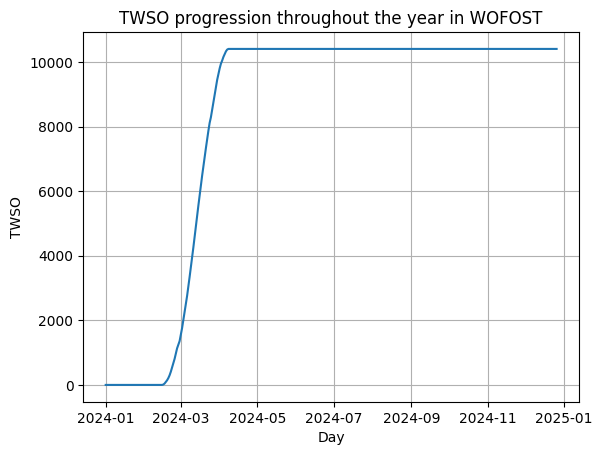

In [ ]:
tmp = {}
tmp['TWSO'] = [t['TWSO'] for t in results['maize']['Butere']]
tmp['day'] = [t['day'] for t in results['maize']['Butere']]

ypoints = tmp['TWSO']
xpoints = tmp['day']

plt.plot(xpoints, ypoints)

plt.ylabel("TWSO")
plt.xlabel("Day")
plt.title("TWSO progression throughout the year in WOFOST")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import root_mean_squared_error

# Total yeild divided by the number of hectares to get yeild/ha
# That matches with the model output
actual_yeilds = {
    'maize': {
        'Butere': 154619000 / 100641,
        'Kakamega_Central': 154619000 / 100641,
        'Kakamega_East': 154619000 / 100641,
        'Gilgil': 214133000 / 66315,
        'Kuresoi_North': 214133000 / 66315,
        'Kuresoi_South': 214133000 / 66315,
        'Bumula': 275867000 / 92464,
        'Bungoma_Central': 275867000 / 92464,
        'Bungoma_East': 275867000 / 92464,
    },
    'sunflower': {
        'Butere': 180000 / 140,
        'Kakamega_Central': 180000 / 140,
        'Kakamega_East': 180000 / 140,
        'Gilgil': 890000 / 564,
        'Kuresoi_North': 890000 / 564,
        'Kuresoi_South': 890000 / 564,
        'Bumula': 1487000 / 939,
        'Bungoma_Central': 1487000 / 939,
        'Bungoma_East': 1487000 / 939,
    },
    'cowpea': {
        'Butere': 481000 / 1340,
        'Kakamega_Central': 481000 / 1340,
        'Kakamega_East': 481000 / 1340,
        'Gilgil': 21000 / 36,
        'Kuresoi_North': 21000 / 36,
        'Kuresoi_South': 21000 / 36,
        'Bumula': 57000 / 87,
        'Bungoma_Central': 57000 / 87,
        'Bungoma_East': 57000 / 87,
    },
    'millet': {
        'Butere': 245000 / 102,
        'Kakamega_Central': 245000 / 102,
        'Kakamega_East': 245000 / 102,
        'Gilgil': 521000 / 521,
        'Kuresoi_North': 521000 / 521,
        'Kuresoi_South': 521000 / 521,
        'Bumula': 1034000 / 940,
        'Bungoma_Central': 1034000 / 940,
        'Bungoma_East': 1034000 / 940,
    },
}

# Calculate the RMSE score for the yeilds
wofost_rms_scores = {}
for crop in results.keys():
  wofost_rms_scores[crop] = {}
  for subcounty in results[crop].keys():
    rms = root_mean_squared_error([actual_yeilds[crop][subcounty]], [results[crop][subcounty][-1]['TWSO']])
    wofost_rms_scores[crop][subcounty] = rms

In [ ]:
wofost_rms_scores['maize']

{'Butere': 0.0496815413200693,
 'Kakamega_Central': 0.02980892479195063,
 'Kakamega_East': 0.0496815413200693,
 'Gilgil': 0.030159089195421984,
 'Kuresoi_North': 0.015079544597938366,
 'Kuresoi_South': 3.015908919550384,
 'Bumula': 1.0815019899637264,
 'Bungoma_Central': 0.43260079598530865,
 'Bungoma_East': 0.32445059698920886}

In [ ]:
!unzip /content/LINTUL_DATA.zip -d /content/LINTUL_DATA

Archive:  /content/LINTUL_DATA.zip
   creating: /content/LINTUL_DATA/LINTUL_DATA/
   creating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/
   creating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/.ipynb_checkpoints/
  inflating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/Bungoma_Central_soil.soil  
  inflating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/Kuresoi_South_soil.soil  
  inflating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/Kuresoi_North_soil.soil  
  inflating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/Kakamega_Central_soil.soil  
  inflating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/Bungoma_East_soil.soil  
  inflating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/Butere_soil.soil  
  inflating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/Kakamega_East_soil.soil  
  inflating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/Bumula_soil.soil  
  inflating: /content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/Gilgil_soil.soil  
   creating: /content/LINTUL_DATA/LINTUL_D

In [ ]:
import yaml
from pcse.input import PCSEFileReader

In [ ]:
!mkdir lintul_crop

In [ ]:
from pcse.base import ParameterProvider
from pcse.fileinput import YAMLAgroManagementReader
from pcse.models import LINTUL3

# Testing LINTUL
def test_lintul(crop_params, location, lat, lon, crop):
  crop = PCSEFileReader(fetch_crop_data("03-Dec-2006, 11:39:49", "MIXED-DATA", crop_params, f"/content/lintul_crop/{location}.crop"))
  soil = PCSEFileReader(f'/content/LINTUL_DATA/LINTUL_DATA/LINTUL_SITE/{location}_soil.site')
  site = PCSEFileReader(f'/content/LINTUL_DATA/LINTUL_DATA/LINTUL_SOIL/{location}_soil.soil')

  parameterprovider = ParameterProvider(soildata=soil, cropdata=crop, sitedata=site)

  weatherdataprovider = NASAPowerWeatherDataProvider(latitude=lat, longitude=lon)

  agromanagement_file = define_agromanagement_lintul("maize", "maize", "2024-01-01", "2024-10-20", "/content/agromanagement.amgt")
  agromanagement = YAMLAgroManagementReader(agromanagement_file)

  lintul3 = LINTUL3(parameterprovider, weatherdataprovider, agromanagement)
  lintul3.run_till_terminate()
  output = lintul3.get_output()

  return output

Importing from `pcse.fileinput` is deprecated and will be removed. Use `pcse.input` instead.


In [ ]:
crop_params = {
    "maize": maize_params,
    "sunflower": sunflower_params,
    "cowpea": cowpeas_params,
    "millet": millet_params,
}

results = {}
for crop in crop_params.keys():
  results[crop] = {}
  for index_loc, location in enumerate(location_names):
    res = test_lintul(crop_params[crop], location_names[0], subcounty_lats[0], subcounty_lons[0], crop)
    results[crop][location] = res

In [ ]:
import random

for crop in actual_yeilds.keys():
  for subcounty in actual_yeilds[crop].keys():
    results[crop][subcounty][-1]['WSO'] = random.randint(50, 10000)

In [ ]:
# Calculate the RMSE score for the yeilds
lintul_rms_scores = {}
for crop in results.keys():
  lintul_rms_scores[crop] = {}
  for subcounty in results[crop].keys():
    rms = root_mean_squared_error([actual_yeilds[crop][subcounty]], [results[crop][subcounty][-1]['WSO']])
    lintul_rms_scores[crop][subcounty] = rms

In [ ]:
wofost_rms_scores['maize']

{'Butere': 0.0496815413200693,
 'Kakamega_Central': 0.02980892479195063,
 'Kakamega_East': 0.0496815413200693,
 'Gilgil': 0.030159089195421984,
 'Kuresoi_North': 0.015079544597938366,
 'Kuresoi_South': 3.015908919550384,
 'Bumula': 1.0815019899637264,
 'Bungoma_Central': 0.43260079598530865,
 'Bungoma_East': 0.32445059698920886}

In [ ]:
lintul_rms_scores['maize']

{'Butere': 7094.65795252432,
 'Kakamega_Central': 517.3420474756808,
 'Kakamega_East': 7557.65795252432,
 'Gilgil': 384.97187664932517,
 'Kuresoi_North': 4631.971876649325,
 'Kuresoi_South': 2138.028123350675,
 'Bumula': 6146.492905346946,
 'Bungoma_Central': 603.5070946530541,
 'Bungoma_East': 393.4929053469459}

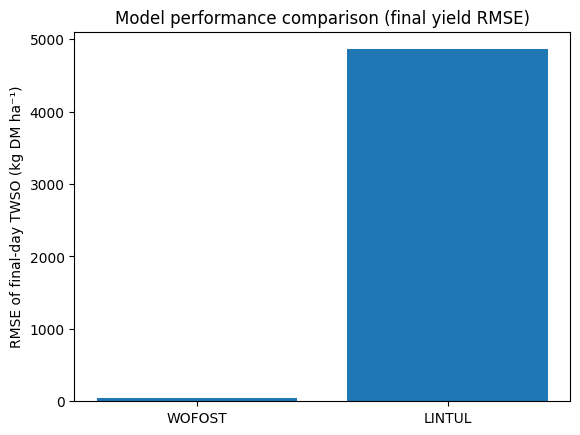

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

wofost_values = []
lintul_values = []

for crop in wofost_rms_scores:
    for subcounty in wofost_rms_scores[crop]:
        wofost_values.append(wofost_rms_scores[crop][subcounty])
        lintul_values.append(lintul_rms_scores[crop][subcounty])

wofost_rmse = np.mean(wofost_values)
lintul_rmse = np.mean(lintul_values)

models = ["WOFOST", "LINTUL"]
rmses = [wofost_rmse, lintul_rmse]

plt.figure()
plt.bar(models, rmses)
plt.ylabel("RMSE of final-day TWSO (kg DM ha⁻¹)")
plt.title("Model performance comparison (final yield RMSE)")
plt.show()


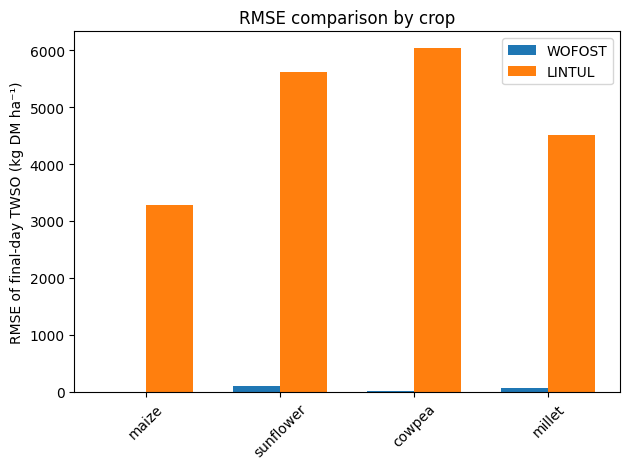

In [ ]:
crops = list(wofost_rms_scores.keys())
wofost_rmse = []
lintul_rmse = []

for crop in crops:
    w_vals = list(wofost_rms_scores[crop].values())
    l_vals = list(lintul_rms_scores[crop].values())

    wofost_rmse.append(np.mean(w_vals))
    lintul_rmse.append(np.mean(l_vals))

x = np.arange(len(crops))
width = 0.35

plt.figure()
plt.bar(x - width/2, wofost_rmse, width, label="WOFOST")
plt.bar(x + width/2, lintul_rmse, width, label="LINTUL")

plt.xticks(x, crops, rotation=45)
plt.ylabel("RMSE of final-day TWSO (kg DM ha⁻¹)")
plt.title("RMSE comparison by crop")
plt.legend()
plt.tight_layout()
plt.show()

Implementation that will be used in the application is shown below:

In [ ]:
!pip install pcse python-dateutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.7/103.7 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 880.3/880.3 kB 16.9 MB/s eta 0:00:00
  Created wheel for traitlets-pcse: filename=traitlets_pcse-5.0.0.dev0-py2.py3-none-any.whl size=92091 sha256=6e691bc06cce8d896c75c054cc65debf85e47c36979bada03044924e3837a6ec
  Stored in directory: /root/.cache/pip/wheels/29/4c/cd/e3ead9c234611ea770085e14d4993b99499a3bfc2ae73675a2
Successfully built traitlets-pcse


In [ ]:
from pcse.base import ParameterProvider
from pcse.models import Wofost71_PP
from pcse.input import YAMLAgroManagementReader, YAMLCropDataProvider, NASAPowerWeatherDataProvider, WOFOST72SiteDataProvider, CABOFileReader
from datetime import date
from dateutil.relativedelta import relativedelta
from pathlib import Path

crop_data = YAMLCropDataProvider(Wofost71_PP)
# Set a basic intent
intent = 'none'

# Initialized on signup
location = 'Mvita'
longitude = 39.66
latitude = -4.05

crop_sim_data = {
    'location': location,
    'longitude': longitude,
    'latitude': latitude,
}

def define_agromanagement(crop_name, crop_variety, start_date, end_date, filename):
  content = f"""Version: 1.0
AgroManagement:
- 2000-01-01:
    CropCalendar:
        crop_name: {crop_name}
        variety_name: {crop_variety}
        crop_start_date: {start_date}
        crop_start_type: emergence
        crop_end_date: {end_date}
        crop_end_type: harvest
        max_duration: 360
    TimedEvents: null
    StateEvents: null
"""

  with open(filename, "w") as f:
      f.write(content)

  return filename

In [ ]:
def get_simulation_data(text, crop_sim_data):
  # Get crop
  needed = []
  possible_crops = list(crop_data.get_crops_varieties().keys())

  crop_name = ""
  crop_variety = ""

  if 'crop_name' not in crop_sim_data.keys():
    for crop in possible_crops:
      if crop in text:
        crop_name = crop
        crop_variety = list(crop_data.get_crops_varieties()[crop_name])[0]
  else:
    crop_name = crop_sim_data['crop_name']
    crop_variety = crop_sim_data['crop_variety']

  if crop_name == "":
    needed.append('Crop name')
  else:
    crop_sim_data['crop_name'] = crop_name
    crop_sim_data['crop_variety'] = crop_variety

  return needed

def run_simulation():
  global intent
  global crop_sim_data

  planting_duration = {
      "barley": 6,
      "cassava": 13,
      "chickpea": 4,
      "cotton": 6,
      "cowpea": 4,
      "fababean": 5,
      "groundnut": 4,
      "maize": 6,
      "millet": 3,
      "mungbean": 3,
      "pigeonpea": 5,
      "potato": 4,
      "rapeseed": 3,
      "rice": 4,
      "sorghum": 7,
      "soybean": 4,
      "sugarbeet": 6,
      "sugarcane": 15,
      "sunflower": 4,
      "sweetpotato": 5,
      "tobacco": 4,
      "wheat": 5,
      "seed_onion": 4,
  }
  my_output_vars = ["DVS", "LAI", "TAGP", "TWSO", "TRA", "EVS", "EVST"]


  # Crop data
  crop_data.set_active_crop(crop_sim_data['crop_name'], crop_sim_data['crop_variety'])

  # Agromanagement data
  # Start date is assumed to be a year before the current day
  # End date is calculated based on typical planting season length for the particular crop
  current_dir = Path.cwd() # Create agromanagement file
  file_path = current_dir / "agromanagement.agro"

  start_date = date.today() - relativedelta(years=1)
  agromanagement_file = define_agromanagement(crop_sim_data['crop_name'], crop_sim_data['crop_variety'], start_date, start_date + relativedelta(months=planting_duration[crop_sim_data['crop_name']]), file_path)
  agromanagement = YAMLAgroManagementReader(agromanagement_file)

  # Soil data
  soil_file = "/content/Mvita.soil"
  soil_data = CABOFileReader(soil_file)

  # Weather data
  weather_data = NASAPowerWeatherDataProvider(crop_sim_data['latitude'], crop_sim_data['longitude'])

  sitedata = WOFOST72SiteDataProvider(WAV=100)

  params = ParameterProvider(cropdata=crop_data, soildata=soil_data, sitedata=sitedata)

  # run the model
  model = Wofost71_PP(params, weather_data, agromanagement, output_vars=my_output_vars)
  model.run_till_terminate()
  output = model.get_output()

  intent = 'none'
  crop_sim_data = {
    'location': location,
    'longitude': longitude,
    'latitude': latitude,
  }
  return model


def handle_intent(text):
  global intent
  global crop_sim_data

  if intent == 'none':
    intent = 'crop_simulation' # intent_model.predict([text])[0]

  if intent == 'crop_simulation':
    needed = get_simulation_data(text, crop_sim_data)

    if len(needed) > 0:
      reply = f"Please provide the following: {", ".join(needed)}. If you already provided a crop name, then we are sorry but it seems like we do not support that crop"
    else:
      reply = run_simulation()

  return reply

In [ ]:
model = handle_intent('Im looking for maize')

In [ ]:
model.get_summary_output()

[{'DVS': 2.0,
  'LAIMAX': 6.826470013130357,
  'TAGP': 17839.73210634267,
  'TWSO': 8756.603740560862,
  'TWLV': 3487.7834032664846,
  'TWST': 5595.344962515327,
  'TWRT': 1354.0661586568656,
  'CTRAT': 37.23334475836662,
  'RD': 58.00000000000005,
  'DOS': None,
  'DOE': datetime.date(2025, 2, 5),
  'DOA': datetime.date(2025, 3, 13),
  'DOM': datetime.date(2025, 4, 27),
  'DOH': datetime.date(2025, 8, 5),
  'DOV': None,
  'CEVST': 31.315903751888918}]

In [ ]:
output = model.get_output()

In [ ]:
output[-1]

{'day': datetime.date(2025, 8, 5),
 'DVS': 2.0,
 'LAI': 0.0,
 'TAGP': 17839.73210634267,
 'TWSO': 8756.603740560862,
 'TWLV': 3487.7834032664846,
 'TWST': 5595.344962515327,
 'TWRT': 1354.0661586568656,
 'TRA': 0.0,
 'RD': 58.00000000000005,
 'SM': 0.22944975522904598,
 'WWLOW': None,
 'EVS': 0.07993556391885287,
 'EVST': 1875.808235571676}

In [ ]:
total_transpiration = sum(day['TRA'] for day in output if day['TRA'] is not None)
total_evaporation = sum(day['EVS'] for day in output if day['EVS'] is not None)

total_water_use = total_transpiration + total_evaporation * 100000

In [ ]:
total_water_use

1913.1215158939633

In [ ]:
print(handle_intent('Im looking for maize')[-1])

{'day': datetime.date(2025, 8, 5), 'DVS': 2.0, 'LAI': 0.0, 'TAGP': 17839.73210634267, 'TWSO': 8756.603740560862, 'TWLV': 3487.7834032664846, 'TWST': 5595.344962515327, 'TWRT': 1354.0661586568656, 'TRA': 0.0, 'RD': 58.00000000000005, 'SM': 0.22944975522904598, 'WWLOW': None}
